In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib

### Loading Data

In [2]:
#Loading the dataset
df = pd.read_csv("../data/Cars.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [3]:
#Checking the total number of rows and columns in dataset
df.shape


(8128, 13)

In [4]:
#Find out the summary of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 1.6 MB


In [5]:
#Check if there is any null values

df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

In [6]:
#Check the statistical summary
df.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [7]:
#Extracting the brand names from name column

df['name'] = df['name'].str.split().str[0]
df = df.rename(columns= {'name': 'brand'})

#Remove LPG and CNG from fuel colum

df = df[df['fuel'].isin(['Diesel','Petrol'])]


#Mapping owner column

owner_map = {'First Owner' : 1,
             'Second Owner' : 2,
             'Third Owner' : 3,
             'Fourth & Above Owner' : 4,
             'Test Drive Car' : 5
             }

df['owner'] = df['owner'].map(owner_map)

#Dropping Test Drive Cars from owner
df = df.drop(df[df['owner'] == 5].index)

#Strip and convert to float type

df['mileage'] = df['mileage'].str.split().str[0].astype(float)
df['engine'] = df['engine'].str.split().str[0].astype(float)
df['max_power'] = df['max_power'].str.split().str[0].astype(float)

#Drop torque column

df = df.drop(columns= ['torque'])




In [8]:
df.head()

,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0
2,Honda,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0


In [9]:
#Check if there are duplicated rows
df.duplicated().sum()

#Remove duplicated rows
df = df.drop_duplicates()

In [10]:
df.shape

(6808, 12)

### EDA

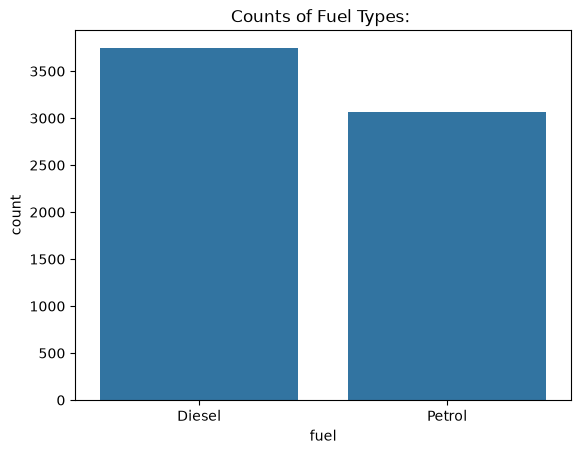

In [11]:
# See the count of Fuel types

sns.countplot(data=df, x='fuel')
plt.title("Counts of Fuel Types: ")
plt.show()

The difference between the counts of both fuel types is around 1000. Both fuel types are well represented and the imbalance is not extreme to perform additional corrections.

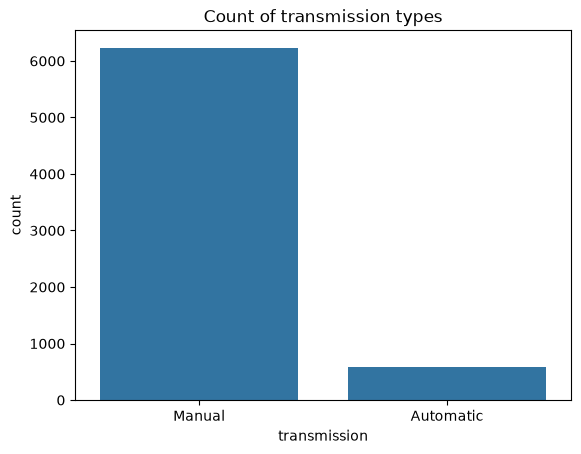

In [12]:
#See the transmission type counts

sns.countplot(data = df, x= 'transmission')
plt.title("Count of transmission types")
plt.show()

The count of automatic transmission cars are far fewer than that of manual ones. It is important to see more how these difference has effect on selling price.


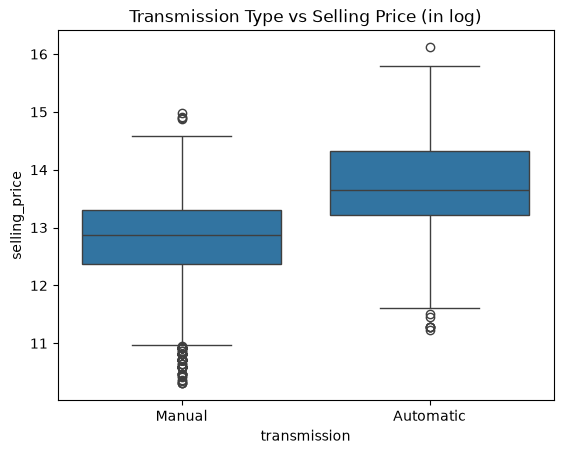

In [13]:
#Find out transmission type vs selling price

sns.boxplot(x= df['transmission'], y = np.log(df['selling_price'])) #used log transformation as the selling price values has big numbers
plt.title("Transmission Type vs Selling Price (in log)")
plt.show()

Looking at these box plots, automatic cars tend to have higher selling prices than manual.

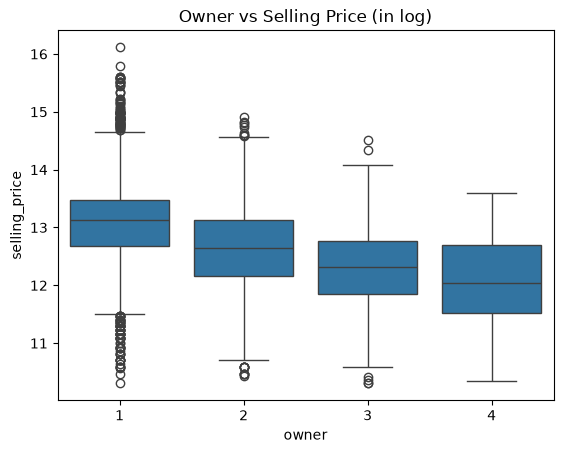

In [14]:
#Find out the relationship between owner and selling price

sns.boxplot(x = df['owner'], y = np.log(df['selling_price']))
plt.title("Owner vs Selling Price (in log)")
plt.show()

First owned cars tend to have higher selling price than that of the remaining owner types. The more the car is pre-owned, the lower the selling price gets.

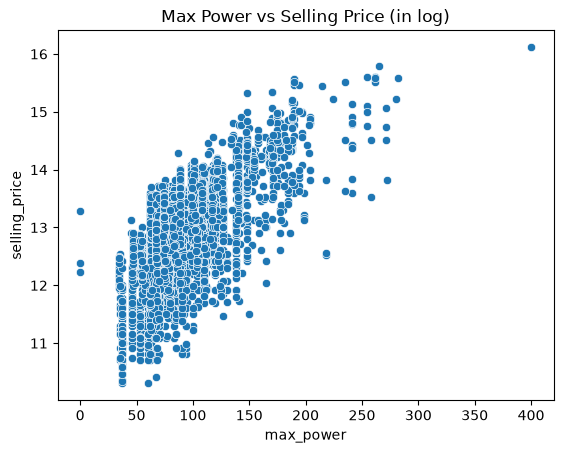

In [15]:
#Find out the relationship between max power and selling price

sns.scatterplot(x = df['max_power'], y = np.log(df['selling_price']))
plt.title("Max Power vs Selling Price (in log)")
plt.show()

It is visible that as the max_power increases, the selling_price also increases which is a positive relationship.

In [16]:
df_corr = df.copy()

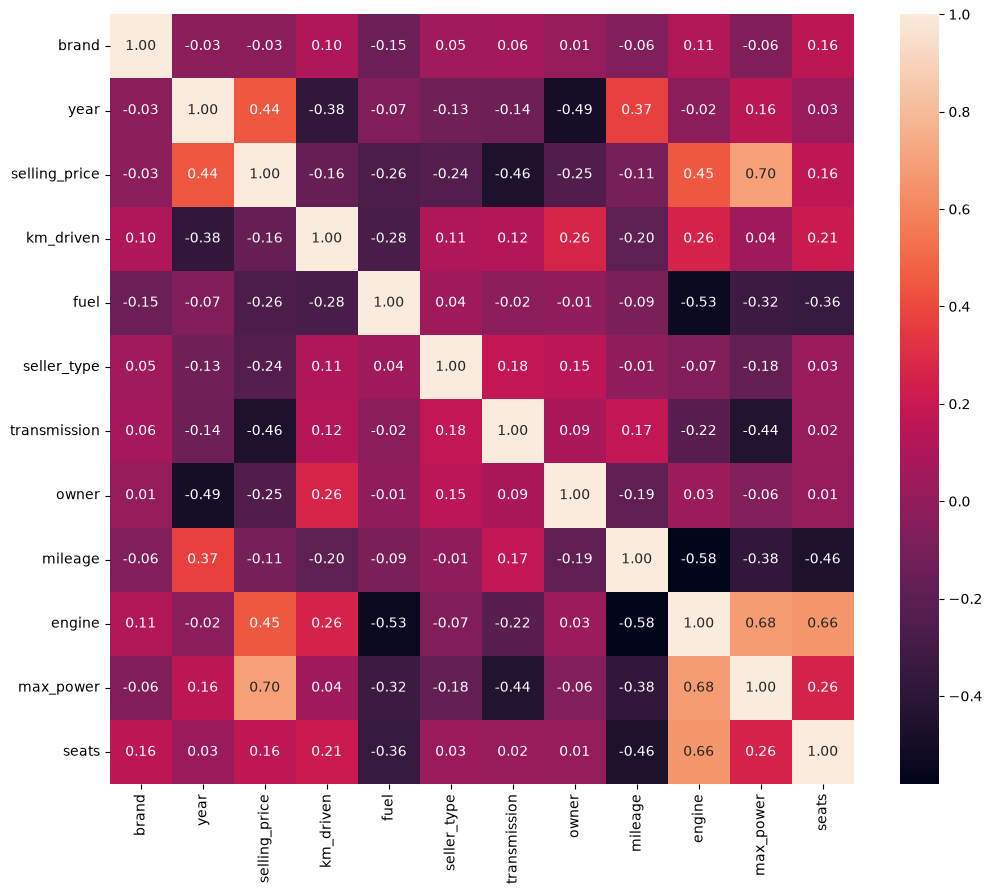

In [17]:
# Correlation heatmap 
# Since there are categorical columns, change them into numeric to find out correlation

for col in ['brand', 'fuel', 'seller_type', 'transmission']:
    df_corr[col] = df_corr[col].astype('category').cat.codes
plt.figure(figsize= (12,10))
sns.heatmap(df_corr.corr(),annot= True, fmt= '.2f')
plt.show()

In this correlation heatmap, it is noted that max_power, engine and year has the most correlation with selling_price.

### Feature Selection

In [18]:
X = df.drop(columns = ['selling_price']) #The features are all of the columns except the label "selling_price"
y = np.log(df['selling_price']) # transform into log as the selling price has big numbers


### Splitting

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state = 42)
X_train.shape,X_test.shape


((4765, 11), (2043, 11))

### Imputation

In [20]:
# Find out the missing values in X_train set

X_train.isna().sum()

brand             0
year              0
km_driven         0
fuel              0
seller_type       0
transmission      0
owner             0
mileage         152
engine          152
max_power       149
seats           152
dtype: int64

In [21]:
X_test.isna().sum()

brand            0
year             0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage         49
engine          49
max_power       49
seats           49
dtype: int64

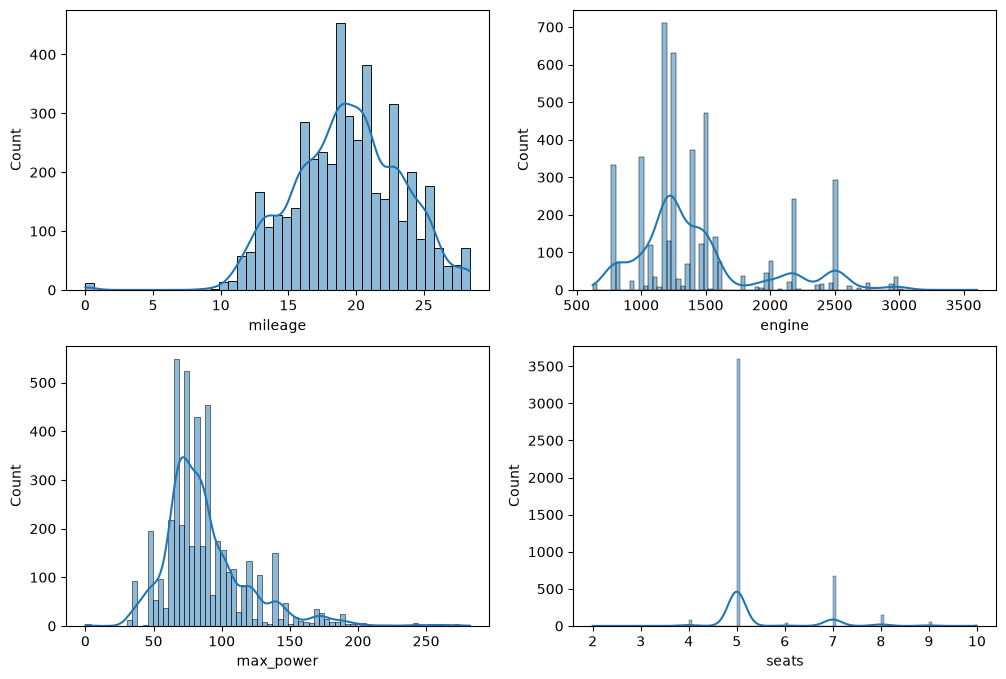

In [22]:
#Before deciding how to fill the missing values, let's check whether the data in mileage, engine, max_power and seats have normal distribution

cols = ['mileage', 'engine', 'max_power', 'seats']
fig, axes = plt.subplots(2,2, figsize =  (12,8))
axes = axes.flatten()

for i,col in enumerate(cols):
    sns.histplot(X_train[col].dropna(),ax = axes[i], kde = True)

    
plt.show()


In [23]:
X_train['mileage'].mean()

np.float64(19.384075438976804)

In [24]:
X_train['mileage'].median()

np.float64(19.4)

While mileage is mildly left-skewed, engine and max_power are right skewed. Therefore, I will impute median values to engine and max_power. To be consistent, I will also impute median values to mileage as well. Mode will be imputed to seats.

In [25]:
#Impute training dataset first

X_train['mileage'] = X_train['mileage'].fillna(X_train['mileage'].median())
X_train['engine'] = X_train['engine'].fillna(X_train['engine'].median())
X_train['max_power'] = X_train['max_power'].fillna(X_train['max_power'].median())
X_train['seats'] = X_train['seats'].fillna(X_train['seats'].mode()[0])

In [26]:
#Check if all those missing values are filled
X_train.isna().sum()

brand           0
year            0
km_driven       0
fuel            0
seller_type     0
transmission    0
owner           0
mileage         0
engine          0
max_power       0
seats           0
dtype: int64

In [27]:
# Now, impute the testing dataset with values from training dataset

X_test['mileage'] = X_test['mileage'].fillna(X_train['mileage'].median())
X_test['engine'] = X_test['engine'].fillna(X_train['engine'].median())
X_test['max_power'] = X_test['max_power'].fillna(X_train['max_power'].median())
X_test['seats'] = X_test['seats'].fillna(X_train['seats'].mode()[0])

In [28]:
X_test.isna().sum()

brand           0
year            0
km_driven       0
fuel            0
seller_type     0
transmission    0
owner           0
mileage         0
engine          0
max_power       0
seats           0
dtype: int64

In [29]:
#Check if there are missing values in y

y_train.isna().sum()

np.int64(0)

In [30]:
y_test.isna().sum()

np.int64(0)

### Encoding

In [31]:
cat_cols = ['brand','fuel','seller_type','transmission'] # The list of categorical features for encoding
num_cols = ['year', 'km_driven','mileage','engine', 'max_power'] #seat is not included as it is discrete and no need to scale, owner is also excluded

encoder = OneHotEncoder(handle_unknown= 'ignore', sparse_output= False)
X_train_cat = encoder.fit_transform(X_train[cat_cols])
X_test_cat = encoder.transform(X_test[cat_cols])



### Scaling

In [32]:
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[num_cols])
X_test_num = scaler.transform(X_test[num_cols])

### Combine encoded and scaled columns together

In [33]:
remaining_cols = ['owner','seats']
col_names = num_cols + remaining_cols + list(encoder.get_feature_names_out(cat_cols))

col_names

['year',
 'km_driven',
 'mileage',
 'engine',
 'max_power',
 'owner',
 'seats',
 'brand_Ambassador',
 'brand_Ashok',
 'brand_Audi',
 'brand_BMW',
 'brand_Chevrolet',
 'brand_Daewoo',
 'brand_Datsun',
 'brand_Fiat',
 'brand_Force',
 'brand_Ford',
 'brand_Honda',
 'brand_Hyundai',
 'brand_Isuzu',
 'brand_Jaguar',
 'brand_Jeep',
 'brand_Kia',
 'brand_Land',
 'brand_Lexus',
 'brand_MG',
 'brand_Mahindra',
 'brand_Maruti',
 'brand_Mercedes-Benz',
 'brand_Mitsubishi',
 'brand_Nissan',
 'brand_Opel',
 'brand_Renault',
 'brand_Skoda',
 'brand_Tata',
 'brand_Toyota',
 'brand_Volkswagen',
 'brand_Volvo',
 'fuel_Diesel',
 'fuel_Petrol',
 'seller_type_Dealer',
 'seller_type_Individual',
 'seller_type_Trustmark Dealer',
 'transmission_Automatic',
 'transmission_Manual']

In [34]:
#Combine X_train first
X_train_final = pd.DataFrame(np.hstack([X_train_num,X_train[remaining_cols].values,X_train_cat]),columns = col_names, index = X_train.index)

In [35]:
print(X_train_final.shape)
print(X_train_final.columns.tolist()) 

(4765, 45)
['year', 'km_driven', 'mileage', 'engine', 'max_power', 'owner', 'seats', 'brand_Ambassador', 'brand_Ashok', 'brand_Audi', 'brand_BMW', 'brand_Chevrolet', 'brand_Daewoo', 'brand_Datsun', 'brand_Fiat', 'brand_Force', 'brand_Ford', 'brand_Honda', 'brand_Hyundai', 'brand_Isuzu', 'brand_Jaguar', 'brand_Jeep', 'brand_Kia', 'brand_Land', 'brand_Lexus', 'brand_MG', 'brand_Mahindra', 'brand_Maruti', 'brand_Mercedes-Benz', 'brand_Mitsubishi', 'brand_Nissan', 'brand_Opel', 'brand_Renault', 'brand_Skoda', 'brand_Tata', 'brand_Toyota', 'brand_Volkswagen', 'brand_Volvo', 'fuel_Diesel', 'fuel_Petrol', 'seller_type_Dealer', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Automatic', 'transmission_Manual']


In [36]:
#Combine X_test

X_test_final = pd.DataFrame(np.hstack([X_test_num, X_test[remaining_cols].values,X_test_cat]), columns= col_names, index = X_test.index)

In [37]:
print(X_test_final.shape)
print(X_test_final.columns.tolist()) 

(2043, 45)
['year', 'km_driven', 'mileage', 'engine', 'max_power', 'owner', 'seats', 'brand_Ambassador', 'brand_Ashok', 'brand_Audi', 'brand_BMW', 'brand_Chevrolet', 'brand_Daewoo', 'brand_Datsun', 'brand_Fiat', 'brand_Force', 'brand_Ford', 'brand_Honda', 'brand_Hyundai', 'brand_Isuzu', 'brand_Jaguar', 'brand_Jeep', 'brand_Kia', 'brand_Land', 'brand_Lexus', 'brand_MG', 'brand_Mahindra', 'brand_Maruti', 'brand_Mercedes-Benz', 'brand_Mitsubishi', 'brand_Nissan', 'brand_Opel', 'brand_Renault', 'brand_Skoda', 'brand_Tata', 'brand_Toyota', 'brand_Volkswagen', 'brand_Volvo', 'fuel_Diesel', 'fuel_Petrol', 'seller_type_Dealer', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Automatic', 'transmission_Manual']


### Modeling with LinearRegression classes

In [38]:
from sklearn.model_selection import KFold
import mlflow


In [39]:
class LinearRegression(object):
    kfold = KFold(n_splits =3)
    #Initialize model
    def __init__(self,regularization, lr = 0.001, num_epochs = 500, method = 'batch',batch_size = 50,cv = kfold, init_method = 'zeros', momentum = 0.0):
        self.regularization = regularization
        self.lr = lr
        self.num_epochs = num_epochs
        self.method = method
        self.batch_size = batch_size
        self.cv = cv
        self.init_method = init_method
        self.momentum = momentum

    #MSE Function
    def mse(self,ytrue, ypred):
        return ((ytrue-ypred)**2).sum() / ytrue.shape[0]

    #R2 score function
    def r2(self,ytrue, ypred):
        ss_res = ((ytrue-ypred) ** 2).sum()
        ss_tot = ((ytrue- ytrue.mean()) ** 2).sum()
        return 1 - (ss_res/ss_tot)

    def fit(self,X_train, y_train):
        self.kfold_scores = list()
        self.val_loss_old = np.inf
        for fold, (train_idx,val_idx) in enumerate(self.cv.split(X_train)):
            X_cross_train = X_train[train_idx]
            y_cross_train = y_train[train_idx]
            X_cross_val = X_train[val_idx]
            y_cross_val = y_train[val_idx]
            n = X_cross_train.shape[1]
            #Add Xavier initialization
            if self.init_method == 'xavier':
                lower, upper = -(1.0 / np.sqrt(n)), (1.0 / np.sqrt(n))
                self.theta = np.random.uniform(lower, upper, n)
            else:
                self.theta = np.zeros(n)
            self.prev_step = np.zeros(n)
            #Start tracking with mlflow
            with mlflow.start_run(run_name = f"Fold - {fold}", nested = True):
                params = {"method" : self.method, "lr" : self.lr, "reg": type(self).__name__}
                mlflow.log_params(params = params)
                for epoch in range(self.num_epochs):
                    perm = np.random.permutation(X_cross_train.shape[0])
                    X_cross_train = X_cross_train[perm]
                    y_cross_train = y_cross_train[perm]
                    #Implement Stochastic method
                    if self.method == 'sto':
                        for batch_idx in range(X_cross_train.shape[0]):
                            X_method_train = X_cross_train[batch_idx].reshape(1,-1)
                            y_method_train = y_cross_train[batch_idx].reshape(-1)
                            train_loss = self._train(X_method_train,y_method_train)
                    #Implement Mini batch method
                    elif self.method == 'mini':
                        for batch_idx in range(0, X_cross_train.shape[0], self.batch_size):
                            X_method_train = X_cross_train[batch_idx:batch_idx+self.batch_size,:]
                            y_method_train = y_cross_train[batch_idx:batch_idx+self.batch_size]
                            train_loss = self._train(X_method_train, y_method_train)
                    #Implement batch method
                    else:
                        X_method_train = X_cross_train
                        y_method_train = y_cross_train
                        train_loss = self._train(X_method_train, y_method_train)

                    mlflow.log_metric(key="train_loss", value=train_loss, step=epoch)

                    yhat_val = self.predict(X_cross_val)
                    val_loss_new = self.mse(y_cross_val, yhat_val)
                    mlflow.log_metric(key="val_loss", value=val_loss_new, step=epoch)
                    
                    if np.allclose(val_loss_new, self.val_loss_old):
                        break
                    self.val_loss_old = val_loss_new                    

                self.kfold_scores.append(val_loss_new)
                print(f"Fold {fold}: {val_loss_new}")

    def _train(self, X, y):
        yhat = self.predict(X)
        m    = X.shape[0]
        #Gradient descent update with momentum        
        grad = (1/m) * X.T @ (yhat - y) + self.regularization.derivation(self.theta)
        step = self.lr * grad
        self.theta = self.theta - step + self.momentum * self.prev_step
        self.prev_step = step
        return self.mse(y, yhat)
    
    def predict(self, X):
        return X @ self.theta
    
    #Return theta
    def _coef(self):
        return self.theta[1:]
    
    #Return Intercept
    def _bias(self):
        return self.theta[0]

    #Plot feature importance
    def feature_importance(self, feature_names=None):
        importance = np.abs(self._coef()) / np.abs(self._coef()).sum()
        if feature_names is not None:
            sorted_idx = np.argsort(importance)
            plt.figure(figsize=(10, 6))
            plt.barh(np.array(feature_names)[sorted_idx], importance[sorted_idx])
            plt.xlabel("Feature Importance")
            plt.title("Feature Importance (Based on Coefficients)")
            plt.tight_layout()
            plt.show()
        return importance
    

In [40]:
#No penalty for normal and polynomial
class NoPenalty:
    def __call__(self, theta):
        return 0
    
    def derivation(self, theta):
        return np.zeros(theta.shape)

 #Lasso penalty   
class LassoPenalty:
    def __init__(self, l):
        self.l = l
    
    def __call__(self, theta):
        return self.l * np.abs(theta).sum()
    
    def derivation(self, theta):
        return self.l * np.sign(theta)

#Ridge penalty
class RidgePenalty:
    def __init__(self, l):
        self.l = l
    
    def __call__(self, theta):
        return self.l * np.sum(theta ** 2)
    
    def derivation(self, theta):
        return self.l * 2 * theta

#ElasticNet
class ElasticPenalty:
    def __init__(self, l=0.1, l_ratio=0.5):
        self.l = l
        self.l_ratio = l_ratio
    
    def __call__(self, theta):
        l1_contrib = self.l_ratio * self.l * np.abs(theta).sum()
        l2_contrib = (1 - self.l_ratio) * self.l * np.sum(theta ** 2)
        return l1_contrib + l2_contrib
    
    def derivation(self, theta):
        l1_contrib = self.l_ratio * self.l * np.sign(theta)
        l2_contrib = (1 - self.l_ratio) * self.l * 2 * theta
        return l1_contrib + l2_contrib
    
#Create subclasses with LinearRegression
class Lasso(LinearRegression):
    def __init__(self, method='batch', lr=0.001, l=0.1, num_epochs=500, batch_size=50, cv=LinearRegression.kfold, init_method='zeros',momentum=0.0):
        self.regularization = LassoPenalty(l)
        super().__init__(self.regularization, lr=lr, method=method, num_epochs=num_epochs, batch_size=batch_size, cv=cv, init_method=init_method, momentum=momentum)

class Ridge(LinearRegression):
    def __init__(self, method='batch', lr=0.001, l=0.1, num_epochs=500, batch_size=50, cv=LinearRegression.kfold, init_method='zeros', momentum=0.0):
        self.regularization = RidgePenalty(l)
        super().__init__(self.regularization, lr=lr, method=method, num_epochs=num_epochs, batch_size=batch_size, cv=cv, init_method=init_method, momentum=momentum)

class ElasticNet(LinearRegression):
    def __init__(self, method='batch', lr=0.001, l=0.1, l_ratio=0.5, num_epochs=500, batch_size=50, cv=LinearRegression.kfold, init_method='zeros', momentum=0.0):
        self.regularization = ElasticPenalty(l, l_ratio)
        super().__init__(self.regularization, lr=lr, method=method, num_epochs=num_epochs, batch_size=batch_size, cv=cv, init_method=init_method, momentum=momentum)
        super().__init__(self.regularization, lr=lr, method=method, num_epochs=num_epochs, batch_size=batch_size, cv=cv)

class Normal(LinearRegression):
    def __init__(self, method='batch', lr=0.001, num_epochs=500, batch_size=50, cv=LinearRegression.kfold, init_method='zeros', momentum=0.0):
        self.regularization = NoPenalty()
        super().__init__(self.regularization, lr=lr, method=method, num_epochs=num_epochs, batch_size=batch_size, cv=cv, init_method=init_method, momentum=momentum)



In [41]:
X_train_np = X_train_final.values
X_test_np = X_test_final.values

#Add intercept colums here
intercept_train = np.ones((X_train_np.shape[0],1))
intercept_test = np.ones((X_test_np.shape[0],1))

X_train_np = np.concatenate((intercept_train, X_train_np), axis = 1)
X_test_np = np.concatenate((intercept_test, X_test_np), axis = 1)

y_train_np = y_train.values
y_test_np = y_test.values

In [42]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_np[:, 1:])  # exclude intercept
X_test_poly = poly.fit_transform(X_test_np[:, 1:])

# re-add intercept
X_train_poly = np.concatenate((np.ones((X_train_poly.shape[0], 1)), X_train_poly), axis=1)
X_test_poly = np.concatenate((np.ones((X_test_poly.shape[0], 1)), X_test_poly), axis=1)

print(f"Original features: {X_train_np.shape[1]}")
print(f"Polynomial features: {X_train_poly.shape[1]}")

Original features: 46
Polynomial features: 1081


In [93]:
import itertools

# Experiment parameters
model_types = ['normal', 'lasso', 'ridge', 'polynomial']
momentums = [0.0, 0.9]
methods = ['batch', 'mini', 'sto']
inits = ['zeros', 'xavier']
lrs = [0.01, 0.001, 0.0001]

results = []
total = len(model_types) * len(momentums) * len(methods) * len(inits) * len(lrs)
run_count = 0

mlflow.set_experiment("A2-Car-Price-Prediction")

for model_type, mom, method, init, lr in itertools.product(model_types, momentums, methods, inits, lrs):
    run_count += 1
    print(f"Run {run_count}/{total}: {model_type}, momentum={mom}, method={method}, init={init}, lr={lr}")
    
    # Select data and model
    if model_type == 'polynomial':
        X_tr, X_te = X_train_poly, X_test_poly
        model = Normal(method=method, lr=lr, num_epochs=50, init_method=init, momentum=mom)
    elif model_type == 'normal':
        X_tr, X_te = X_train_np, X_test_np
        model = Normal(method=method, lr=lr, num_epochs=50, init_method=init, momentum=mom)
    elif model_type == 'lasso':
        X_tr, X_te = X_train_np, X_test_np
        model = Lasso(method=method, lr=lr, l=0.1, num_epochs=50, init_method=init, momentum=mom)
    elif model_type == 'ridge':
        X_tr, X_te = X_train_np, X_test_np
        model = Ridge(method=method, lr=lr, l=0.1, num_epochs=50, init_method=init, momentum=mom)
    
    with mlflow.start_run(run_name=f"{model_type}_{method}_{init}_lr{lr}_mom{mom}"):
        mlflow.log_params({
            "model_type": model_type,
            "method": method,
            "init_method": init,
            "lr": lr,
            "momentum": mom
        })
        
        model.fit(X_tr, y_train_np)
        
        # Evaluate on test set
        yhat_test = model.predict(X_te)
        test_mse = model.mse(y_test_np, yhat_test)
        test_r2 = model.r2(y_test_np, yhat_test)
        
        mlflow.log_metrics({"test_mse": test_mse, "test_r2": test_r2})
        
        results.append({
            "model_type": model_type,
            "method": method,
            "init": init,
            "lr": lr,
            "momentum": mom,
            "test_mse": test_mse,
            "test_r2": test_r2
        })

print("Done.")

Run 1/144: normal, momentum=0.0, method=batch, init=zeros, lr=0.01
Fold 0: 2.642243721329231
Fold 1: 2.4870302910086775
Fold 2: 2.514960721620564
Run 2/144: normal, momentum=0.0, method=batch, init=zeros, lr=0.001
Fold 0: 7.875363785319558
Fold 1: 8.241385356908792
Fold 2: 8.027880264423132
Run 3/144: normal, momentum=0.0, method=batch, init=zeros, lr=0.0001
Fold 0: 116.6365363278269
Fold 1: 117.20384009095915
Fold 2: 117.31090997435184
Run 4/144: normal, momentum=0.0, method=batch, init=xavier, lr=0.01
Fold 0: 2.74284098608596
Fold 1: 2.5096551971962144
Fold 2: 2.3746309233560208
Run 5/144: normal, momentum=0.0, method=batch, init=xavier, lr=0.001
Fold 0: 8.361110011902676
Fold 1: 8.1992332034943
Fold 2: 8.230499399772095
Run 6/144: normal, momentum=0.0, method=batch, init=xavier, lr=0.0001
Fold 0: 113.94085726679971
Fold 1: 113.5636679394392
Fold 2: 131.324610298494
Run 7/144: normal, momentum=0.0, method=mini, init=zeros, lr=0.01
Fold 0: 0.35761146351205175
Fold 1: 0.362664112461497

/tmp/ipykernel_828/3068942829.py:14: RuntimeWarning: overflow encountered in square
  return ((ytrue-ypred)**2).sum() / ytrue.shape[0]
/Projects/car-price-prediction-a2/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


Fold 0: inf
Fold 1: inf
Fold 2: inf


/tmp/ipykernel_828/3068942829.py:17: RuntimeWarning: overflow encountered in square
  ss_res = ((ytrue-ypred) ** 2).sum()


Run 116/144: polynomial, momentum=0.0, method=mini, init=zeros, lr=0.001
Fold 0: 0.20965629568792585
Fold 1: 0.18554657059578436
Fold 2: 0.19530191224388996
Run 117/144: polynomial, momentum=0.0, method=mini, init=zeros, lr=0.0001
Fold 0: 2.6735950814114844
Fold 1: 2.669187589887224
Fold 2: 2.6559834812083585
Run 118/144: polynomial, momentum=0.0, method=mini, init=xavier, lr=0.01
Fold 0: inf
Fold 1: inf
Fold 2: inf
Run 119/144: polynomial, momentum=0.0, method=mini, init=xavier, lr=0.001
Fold 0: 0.19337043538996332
Fold 1: 0.19140410028480123
Fold 2: 0.19548863441066985
Run 120/144: polynomial, momentum=0.0, method=mini, init=xavier, lr=0.0001
Fold 0: 2.662762376243693
Fold 1: 2.7141200774014482
Fold 2: 2.705011934299789
Run 121/144: polynomial, momentum=0.0, method=sto, init=zeros, lr=0.01


/tmp/ipykernel_828/3068942829.py:74: RuntimeWarning: overflow encountered in matmul
  grad = (1/m) * X.T @ (yhat - y) + self.regularization.derivation(self.theta)
/tmp/ipykernel_828/3068942829.py:74: RuntimeWarning: invalid value encountered in matmul
  grad = (1/m) * X.T @ (yhat - y) + self.regularization.derivation(self.theta)
/tmp/ipykernel_828/3068942829.py:76: RuntimeWarning: invalid value encountered in subtract
  self.theta = self.theta - step + self.momentum * self.prev_step
/tmp/ipykernel_828/3068942829.py:76: RuntimeWarning: invalid value encountered in multiply
  self.theta = self.theta - step + self.momentum * self.prev_step


Fold 0: nan


/tmp/ipykernel_828/3068942829.py:81: RuntimeWarning: invalid value encountered in matmul
  return X @ self.theta


Fold 1: nan
Fold 2: nan
Run 122/144: polynomial, momentum=0.0, method=sto, init=zeros, lr=0.001
Fold 0: inf
Fold 1: inf
Fold 2: inf
Run 123/144: polynomial, momentum=0.0, method=sto, init=zeros, lr=0.0001
Fold 0: 0.10546475842957669
Fold 1: 0.10716094860383164
Fold 2: 0.111999970099757
Run 124/144: polynomial, momentum=0.0, method=sto, init=xavier, lr=0.01
Fold 0: nan
Fold 1: nan
Fold 2: nan
Run 125/144: polynomial, momentum=0.0, method=sto, init=xavier, lr=0.001
Fold 0: inf
Fold 1: inf
Fold 2: inf
Run 126/144: polynomial, momentum=0.0, method=sto, init=xavier, lr=0.0001
Fold 0: 0.11448274572383428
Fold 1: 0.11398770369058397
Fold 2: 0.13888529081889922
Run 127/144: polynomial, momentum=0.9, method=batch, init=zeros, lr=0.01
Fold 0: 1.27004016999941e+112
Fold 1: 1.0593543453832856e+113
Fold 2: 4.744818780101715e+112
Run 128/144: polynomial, momentum=0.9, method=batch, init=zeros, lr=0.001
Fold 0: 9427355520.926973
Fold 1: 83488187930.01323
Fold 2: 36561909159.66917
Run 129/144: polynom

50 epochs was used for the grid search to keep runtime more manageable than that of larger epochs. 

In [43]:
#saving the result to csv file
import pandas as pd

#this was use to import dataframe to csv
# results_df = pd.DataFrame(results)
# results_df.to_csv("../data/experiment_results.csv", index=False) 

#retrieve results from saved csv
results_df = pd.read_csv("../data/experiment_results.csv")

In [44]:
#see the top 10 models by R2
print("Top 10 by R2:")
print(results_df.sort_values("test_r2", ascending = False).head(10)) #R2 score should be high
print("Top 10 by MSE:")
print(results_df.sort_values("test_mse", ascending = True).head(10)) #MSE value should be low


Top 10 by R2:
     model_type method    init      lr  momentum  test_mse   test_r2
13       normal    sto   zeros  0.0010       0.0  0.071096  0.872564
16       normal    sto  xavier  0.0010       0.0  0.071488  0.871863
33       normal    sto  xavier  0.0100       0.9  0.072006  0.870933
15       normal    sto  xavier  0.0100       0.0  0.074028  0.867308
30       normal    sto   zeros  0.0100       0.9  0.076568  0.862756
12       normal    sto   zeros  0.0100       0.0  0.091707  0.835620
122  polynomial    sto   zeros  0.0001       0.0  0.291077  0.478260
9        normal   mini  xavier  0.0100       0.0  0.373691  0.330180
6        normal   mini   zeros  0.0100       0.0  0.380028  0.318821
125  polynomial    sto  xavier  0.0001       0.0  0.406602  0.271188
Top 10 by MSE:
     model_type method    init      lr  momentum  test_mse   test_r2
13       normal    sto   zeros  0.0010       0.0  0.071096  0.872564
16       normal    sto  xavier  0.0010       0.0  0.071488  0.871863
33   

Looking at the MSE and R2 values, the best performing model combination is normal regression with stochastic, zero init, 0.001 learning rate and 0.0 momentum.

In [45]:
#train with the best model with more epochs
best_model = Normal(method='sto',init_method= 'zeros', num_epochs= 500, lr = 0.001, momentum = 0.0)

with mlflow.start_run(run_name = 'best_model_final'):
    best_model.fit(X_train_np, y_train_np)
    yhat_test = best_model.predict(X_test_np)
    final_mse = best_model.mse(y_test_np, yhat_test)
    final_r2 = best_model.r2(y_test_np, yhat_test)
    mlflow.log_metrics({"test_mse": final_mse, "test_r2": final_r2})
    print(f"Final MSE: {final_mse}")
    print(f"Final R2: {final_r2}")
    



    

Fold 0: 0.07654035258204331
Fold 1: 0.07043962769507367
Fold 2: 0.08122795502062545
Final MSE: 0.06368124113898732
Final R2: 0.8858549052065341


### Feature Importance

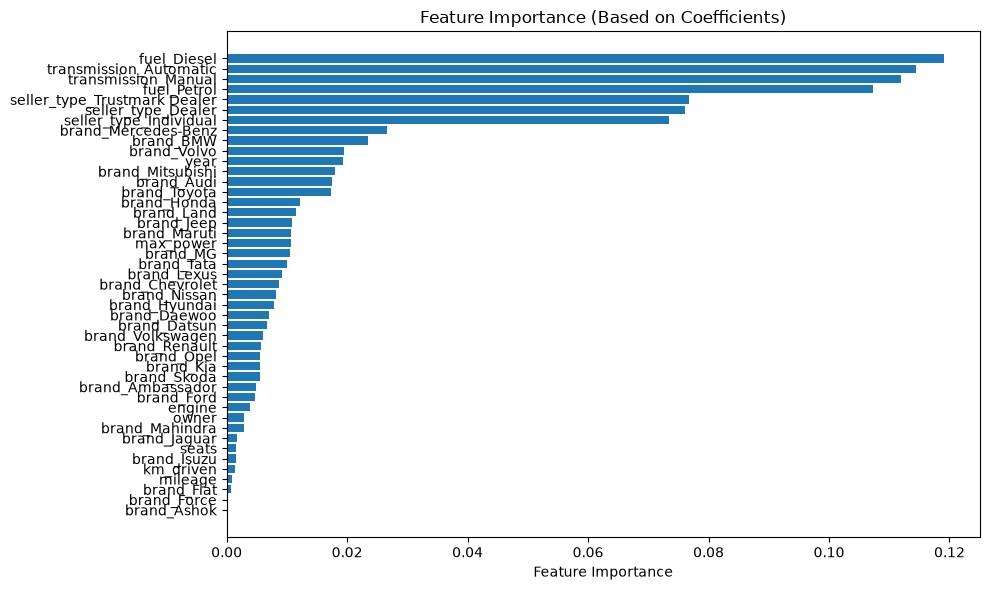

array([0.01925861, 0.00134847, 0.00082818, 0.00383796, 0.01069519,
       0.00285263, 0.00161777, 0.00487571, 0.        , 0.01745649,
       0.02342589, 0.00864528, 0.00702339, 0.00661443, 0.00070999,
       0.00025638, 0.00469333, 0.01212134, 0.00792264, 0.00150097,
       0.00169527, 0.01084464, 0.00548337, 0.01144192, 0.00924411,
       0.01046337, 0.00284025, 0.010752  , 0.02663128, 0.01795971,
       0.00822393, 0.00554194, 0.00566625, 0.0054825 , 0.01005501,
       0.01730814, 0.0060489 , 0.01947684, 0.11910913, 0.10727618,
       0.07607566, 0.07347905, 0.07683059, 0.11436003, 0.11202527])

In [47]:
#plot feature importance

best_model.feature_importance(feature_names=col_names)

The most important features are fuel type (Automatic/Manual) and transmission type (Diesel/Petrol) and followed by seller type and brands such as Volvo and Mercedes-Benz.

In [48]:
#create a comparison table

summary = results_df.groupby("model_type").agg(
    best_r2 = ("test_r2", "max"),
    best_mse = ("test_mse", "min"),

).round(4)
summary.sort_values("best_r2", ascending = False)


,best_r2,best_mse
model_type,,
normal,0.8726,0.0711
polynomial,0.4783,0.2911
lasso,0.1600,0.4686
ridge,-1.6307,1.4677


### Report

**Experiment Summary**

144 experiments were conducted combining 4 model types (Normal, Polynomial, Lasso, Ridge), 2 momentum settings (0.0, 0.9), 3 gradient descent methods (batch, stochastic, mini-batch), 2 initialization methods (zeros, xavier), and 3 learning rates (0.01, 0.001, 0.0001). All experiments used 50 epochs with 3-fold cross-validation and tracked with MLflow.

**Key Findings**

1. **Best model**: Normal (no regularization) with stochastic gradient descent, zeros initialization, lr=0.001, momentum = 0.0. Resulted with R2 = 0.884 and MSE = 0.065 on the test set (retrained with 500 epochs).

2. **Stochastic gradient descent** perfomed the best. This is likely because stochastic updates the weights after every sample, allowing faster convergence.

3. **Regularization did not make difference**. The Normal model outperformed both, suggesting the car price dataset does not suffer from overfitting with these features.

4. **Polynomial features performed poorly**, likely due to the large number of generated features causing overfitting.

5. **Xavier vs zeros initialization** showed minimal difference (R2 difference < 0.001). This is likely due to the standardized data in the earlier processes.

6. **Momentum showed minimal impact**. Momentum 0.9 resulted with R2 = 0.8709 and momentum 0.0 achieved R2 = 0.8726. While the difference is marginal, no momentum model  ranked first.

7. **Limitation**: 50 epochs was used for the grid search to keep runtime manageable. Slower-converging configurations (e.g., batch with lr=0.0001) may be underrepresented in the comparison.

### MLflow Screenshots

**Experiment Run List**
![Experiment Run List](../docs/Experiments.png)

**Best Model Overview**
![Best Model Overview](../docs/BestModelOverview.png)

**Best Model Metrics**
![Best Model Metrics](../docs/BestModelMetrics.png)

**Comparison View**
![Comparison View](../docs/Comparison.png)

In [46]:
import joblib

joblib.dump(best_model, "../app/code/new_model.pkl")
print("Model saved!")

Model saved!
